In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,average_precision_score,
    classification_report
)
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder
import optuna
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [148]:
df= pd.read_excel('dataset_20260430.csv.xlsx')

In [149]:
df.head(2)

,user_id,registration_timestamp,email_domain,age,gender,job_title,education_level,is_smoker,is_drinker,os,device_type,registration_duration_ms,is_fraud
0,e0adb1b0-7300-4f1c-a6c6-6d166cdfa2a6,2025-01-01T00:00:56.670990,hotmail.com,68,F,Mid-Level,High School,False,True,windows,desktop,14544.058189,False
1,8d135521-b7b3-42bf-a6c8-1a9fe078e571,2025-01-01T00:01:03.080025,gmail.com,57,F,Mid-Level,Bachelors,False,False,windows,desktop,11601.448980,False


### Feature Engineering

Based on the understanding gained during **Task 1**, I directly focused on feature engineering for this task:

- **Registration Time Buckets:** Extracted temporal information from `registration_timestamp` and grouped registrations into meaningful time buckets (e.g., Midnight, Early Morning, Morning, Afternoon, Evening, and Night) to capture time-based behavioral patterns.

- **Ordinal Encoding:** Converted inherently ordered categorical features into ordinal numerical representations instead of using nominal encoding:
  - **Job Title:** `Junior < Mid-Level < Manager < Director < CEO`
  - **Education Level:** `High School < Bachelors < Masters < PhD`

These transformations were designed to provide the model with richer temporal information and preserve the natural ordering present in the categorical features.

In [150]:
df['registration_timestamp'] = pd.to_datetime(df['registration_timestamp'])

def time_bucket(ts):
    hour = ts.hour

    if 0 <= hour < 6:
        return 'Midnight'
    elif 6 <= hour < 9:
        return 'Early Morning'
    elif 9 <= hour < 12:
        return 'Mid-Morning'
    elif 12 <= hour < 15:
        return 'Afternoon'
    elif 15 <= hour < 18:
        return 'Late Afternoon'
    elif 18 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['registration_time_bucket'] = df['registration_timestamp'].apply(time_bucket)

In [151]:
job_title_mapping = {
    'Junior': 0,
    'Mid-Level': 1,
    'Manager': 2,
    'Director': 3,
    'CEO': 4
}

education_mapping = {
    'High School': 0,
    'Bachelors': 1,
    'Masters': 2,
    'PhD': 3
}

df['job_title'] = df['job_title'].map(job_title_mapping)
df['education_level'] = df['education_level'].map(education_mapping)

In [152]:
df.head(2)

,user_id,registration_timestamp,email_domain,age,gender,job_title,education_level,is_smoker,is_drinker,os,device_type,registration_duration_ms,is_fraud,registration_time_bucket
0,e0adb1b0-7300-4f1c-a6c6-6d166cdfa2a6,2025-01-01 00:00:56.670990,hotmail.com,68,F,1,0.0,False,True,windows,desktop,14544.058189,False,Midnight
1,8d135521-b7b3-42bf-a6c8-1a9fe078e571,2025-01-01 00:01:03.080025,gmail.com,57,F,1,1.0,False,False,windows,desktop,11601.448980,False,Midnight


In [153]:
# -------------------------------------------------------
# Separate features (X) and target variable (y)
# -------------------------------------------------------
# Drop:
# - registration_timestamp: Already consumed during feature engineering
#   (e.g., extracted registration time buckets).
# - user_id: Unique identifier with no predictive value.
# - is_fraud: Target variable to be predicted.
X = df.drop(['registration_timestamp', 'user_id', 'is_fraud'], axis=1)
y = df['is_fraud']

# -------------------------------------------------------
# Split data into training and testing sets
# -------------------------------------------------------
# 80% Training Data, 20% Testing DataRandom and state ensures reproducibility.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -------------------------------------------------------
# Identify categorical features
# -------------------------------------------------------
# Select columns having object or category datatype.
cat_cols = X_train.select_dtypes(
    include=['object', 'category']
).columns

# -------------------------------------------------------
# One-Hot Encoding
# -------------------------------------------------------
# Convert categorical variables into numerical format.
#
# drop='first'
#   Removes one dummy variable from each category to avoid
#   multicollinearity (dummy variable trap).
#
# handle_unknown='ignore'
#   Ignores unseen categories appearing in the test set
#   instead of throwing an error.
#
# sparse_output=False
#   Returns a dense NumPy array for easier manipulation.
encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

# -------------------------------------------------------
# Fit encoder on training data and transform it
# -------------------------------------------------------
# The encoder learns category mappings only from the
# training data to prevent data leakage.
X_train_encoded = encoder.fit_transform(X_train[cat_cols])

# -------------------------------------------------------
# Transform test data using the same learned mappings
# -------------------------------------------------------
# No fitting is performed on the test data.
X_test_encoded = encoder.transform(X_test[cat_cols])

In [154]:
X_train_encoded

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(40000, 14))

In [155]:
# Convert encoded arrays to DataFrames
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index
)

# Numerical columns
num_cols = X_train.drop(columns=cat_cols).columns

# Combine numerical and encoded features
X_train_final = pd.concat(
    [X_train[num_cols], X_train_encoded_df],
    axis=1
)

X_test_final = pd.concat(
    [X_test[num_cols], X_test_encoded_df],
    axis=1
)


In [156]:
X_train_final.head()

,age,job_title,education_level,is_smoker,is_drinker,registration_duration_ms,email_domain_hotmail.com,email_domain_outlook.com,email_domain_yahoo.com,gender_M,os_ios,os_macos,os_windows,device_type_mobile,registration_time_bucket_Early Morning,registration_time_bucket_Evening,registration_time_bucket_Late Afternoon,registration_time_bucket_Mid-Morning,registration_time_bucket_Midnight,registration_time_bucket_Night
39087,24,3,0.0,False,False,17783.581121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
30893,38,0,0.0,False,True,16540.161258,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
45278,30,0,1.0,False,True,14421.710858,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16398,33,1,0.0,True,True,15530.942631,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
13653,43,1,2.0,False,False,14249.951422,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


## Model Development

Based on the exploratory analysis performed in **Task 1** and the structured nature of the dataset, I chose **XGBoost** as the primary classification algorithm. From both experience and literature, XGBoost generally performs well on structured/tabular datasets due to its ability to capture non-linear relationships while effectively handling mixed feature types.

To identify the most suitable model configuration, I experimented with multiple approaches:

1. **Hyperparameter Optimization**
   - Perfomrmed hyperparameter tuning using **Optuna** to optimize the XGBoost model for improved predictive performance.

2. **Handling Class Imbalance**
   - Incorporated `scale_pos_weight` to compensate for the approximately 5% positive (fraud) class and evaluated its impact on Precision, Recall, F1-score, and PR-AUC.

3. **Baseline Mode**
   - Trained an XGBoost classifier by treating all categorical variables as nominal and applying One-Hot Encoding, including `job_title` and `education_level`.

4. **Stratified Train-Test Split**
    - Used a stratified train-test split to preserve the original class distribution in both training and testing datasets, ensuring a more reliable evaluation. 

The detailed implementation and performance comparison for all four scenarios are provided in the **Appendix**.

### Final Model

The best balance between **Precision** and **Recall** was achieved by:

- Encoding **`job_title`** and **`education_level`** as **ordinal features**, preserving their inherent ordering.
- Treating all remaining categorical variables as **nominal** and applying **One-Hot Encoding**.
- Training an XGBoost classifier using the engineered feature set.

The performance of the final model is summarized below:

In [157]:
# -----------------------------
# Create Model
# -----------------------------
model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    eval_metric='logloss',
    
)

# -----------------------------
# Train
# -----------------------------
model.fit(X_train_final, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test_final)
y_prob = model.predict_proba(X_test_final)[:, 1]


### Test Evaluation

Although the trained model achieved a strong overall performance, the default classification threshold of **0.5** resulted in an imbalance between **Precision** and **Recall**, which is common for imbalanced fraud detection datasets.

To obtain a better trade-off, the **Precision-Recall (PR) Curve** was analyzed, and an optimal decision threshold was selected based on the desired balance between Precision and Recall. Applying this optimized threshold improved the balance between the two metrics, resulting in a more practical model for fraud detection while maintaining strong overall predictive performance.

In [158]:

# -----------------------------
# Evaluation
# -----------------------------
#print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("ROC-AUC  :", average_precision_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Precision: 0.752
Recall   : 0.6197802197802198
F1 Score : 0.6795180722891566
ROC-AUC  : 0.9627925557941273
ROC-AUC  : 0.7416235816597972

Confusion Matrix
[[9452   93]
 [ 173  282]]

Classification Report
              precision    recall  f1-score   support

       False       0.98      0.99      0.99      9545
        True       0.75      0.62      0.68       455

    accuracy                           0.97     10000
   macro avg       0.87      0.81      0.83     10000
weighted avg       0.97      0.97      0.97     10000



### Training Analysis

The training results suggest that the current model has captured the available patterns in the dataset reasonably well. Based on the SHAP analysis, a few features contribute significantly to the model's predictions, while others (e.g., `is_drinker` and `is_smoker`) exhibit minimal importance and appear to behave like noisy features.

I experimented with removing these low-importance features; however, this resulted in a slight decline in model performance. This indicates that although these features have relatively low individual importance, they may still provide complementary information through interactions with other variables.

Overall, the results suggest that further performance improvements are more likely to come from incorporating additional informative features rather than removing existing ones. Examples include behavioral, historical, or device-level features, which could provide stronger predictive signals for fraud detection.

In [159]:
# Training predictions
y_train_pred = model.predict(X_train_final)
y_train_prob = model.predict_proba(X_train_final)[:, 1]

print("===== Training Performance =====")
print("Precision :", precision_score(y_train, y_train_pred))
print("Recall    :", recall_score(y_train, y_train_pred))
print("F1 Score  :", f1_score(y_train, y_train_pred))
print("ROC-AUC   :", roc_auc_score(y_train, y_train_prob))
print("PR-AUC    :", average_precision_score(y_train, y_train_prob))

print(classification_report(y_train, y_train_pred))

===== Training Performance =====
Precision : 0.878169449598021
Recall    : 0.6943765281173594
F1 Score  : 0.7755324959038776
ROC-AUC   : 0.983452454151245
PR-AUC    : 0.8643574295436013
              precision    recall  f1-score   support

       False       0.98      0.99      0.99     37955
        True       0.88      0.69      0.78      2045

    accuracy                           0.98     40000
   macro avg       0.93      0.84      0.88     40000
weighted avg       0.98      0.98      0.98     40000



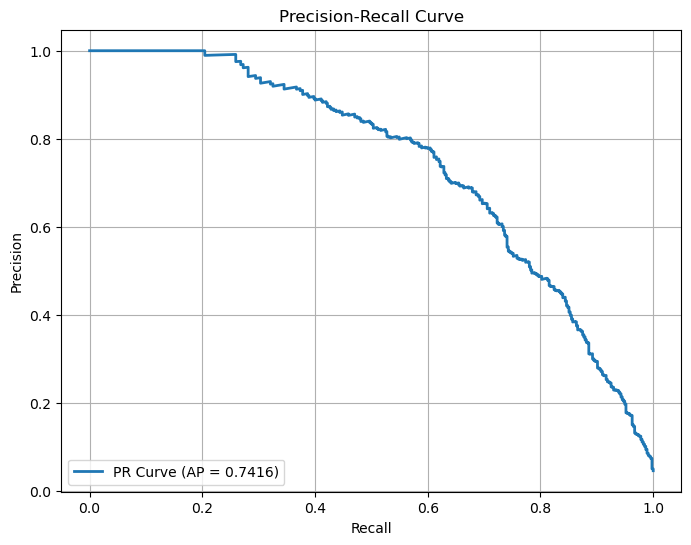

In [160]:
# Predicted probabilities
y_prob = model.predict_proba(X_test_final)[:, 1]

# Compute Precision-Recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Average Precision (AP)
ap_score = average_precision_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8,6))
plt.plot(recall, precision, linewidth=2,
         label=f'PR Curve (AP = {ap_score:.4f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.legend(loc="lower left")
plt.show()

In [161]:
# Calculate F1 for each threshold
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

best_idx = np.argmax(f1_scores)

print(f"Best Threshold : {thresholds[best_idx]:.4f}")
print(f"Precision      : {precision[best_idx]:.4f}")
print(f"Recall         : {recall[best_idx]:.4f}")
print(f"F1 Score       : {f1_scores[best_idx]:.4f}")

Best Threshold : 0.3894
Precision      : 0.6882
Recall         : 0.6791
F1 Score       : 0.6836


In [162]:
best_threshold = thresholds[best_idx]

y_pred = (y_prob >= best_threshold).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.98      0.99      0.99      9545
        True       0.69      0.68      0.68       455

    accuracy                           0.97     10000
   macro avg       0.84      0.83      0.83     10000
weighted avg       0.97      0.97      0.97     10000

[[9405  140]
 [ 146  309]]


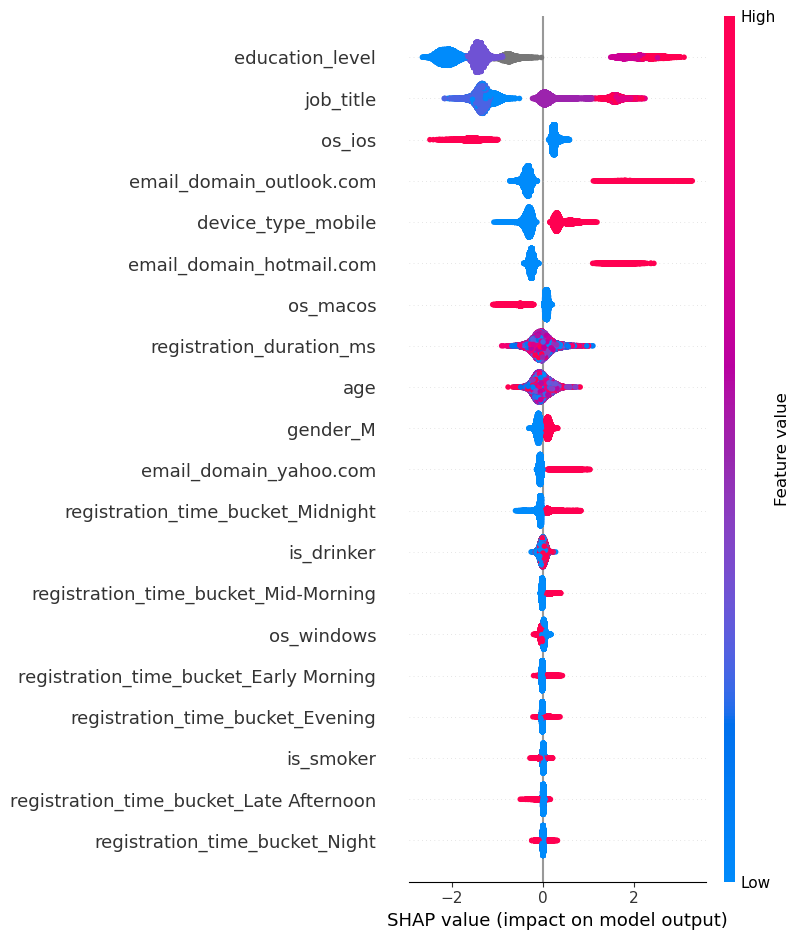

In [163]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_final)

shap.summary_plot(
    shap_values,
    X_train_final,
    max_display=26
)

# Further Steps

## Appendi - 1

##  1. Hyperparameter Optimization - Optuna

In [164]:
def objective(trial):

    params = {
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "random_state": 42,
        "tree_method": "hist",      # Faster
        "n_jobs": -1,

        "n_estimators": trial.suggest_int("n_estimators", 200, 800),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.2,
            log=True
        ),

        "max_depth": trial.suggest_int("max_depth", 3, 10),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            5
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0.1,
            10,
            log=True
        )
    }

    model = XGBClassifier(**params)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train_final,
        y_train,
        cv=cv,
        scoring="average_precision",
        n_jobs=-1
    ).mean()

    return score

In [131]:
study = optuna.create_study(
    direction="maximize",
    study_name="XGBoost_PRAUC"
)

study.optimize(
    objective,
    n_trials=20,
    show_progress_bar=True
)

[I 2026-06-27 10:43:16,914] A new study created in memory with name: XGBoost_PRAUC


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-06-27 10:43:27,102] Trial 0 finished with value: 0.7880595954293325 and parameters: {'n_estimators': 242, 'learning_rate': 0.04187535984775651, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.9401321069236709, 'colsample_bytree': 0.928906918721299, 'gamma': 0.36018147816204826, 'reg_alpha': 4.244136832817031, 'reg_lambda': 1.0113060406860674}. Best is trial 0 with value: 0.7880595954293325.
[I 2026-06-27 10:43:35,180] Trial 1 finished with value: 0.7894345281704787 and parameters: {'n_estimators': 210, 'learning_rate': 0.05155438477701094, 'max_depth': 9, 'min_child_weight': 8, 'subsample': 0.9925790919038108, 'colsample_bytree': 0.8171514465795049, 'gamma': 3.4759695306472196, 'reg_alpha': 4.518000174279775, 'reg_lambda': 7.876100202876604}. Best is trial 1 with value: 0.7894345281704787.
[I 2026-06-27 10:43:44,159] Trial 2 finished with value: 0.7904487025100857 and parameters: {'n_estimators': 277, 'learning_rate': 0.01893710450230485, 'max_depth': 8, 'min_child_weight

In [132]:
print("Best PR-AUC :", study.best_value)

print("\nBest Parameters")

for k, v in study.best_params.items():
    print(f"{k}: {v}")

Best PR-AUC : 0.7920491616922947

Best Parameters
n_estimators: 785
learning_rate: 0.011881558634818892
max_depth: 7
min_child_weight: 1
subsample: 0.7379442618057741
colsample_bytree: 0.7060005293148474
gamma: 4.983540384552587
reg_alpha: 1.5283514389399406
reg_lambda: 0.1217823902375851


In [133]:
best_model = XGBClassifier(
    **study.best_params,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42
)

best_model.fit(X_train_final, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7060005293148474
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'aucpr'


In [134]:
y_pred = best_model.predict(X_test_final)
y_prob = best_model.predict_proba(X_test_final)[:,1]

print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1        :", f1_score(y_test, y_pred))
print("ROC-AUC   :", roc_auc_score(y_test, y_prob))
print("PR-AUC    :", average_precision_score(y_test, y_prob))

Precision : 0.7722222222222223
Recall    : 0.610989010989011
F1        : 0.6822085889570552
ROC-AUC   : 0.9680345845877538
PR-AUC    : 0.7608951051965495


### Hyperparameter Tuning

Hyperparameter optimization was performed using **Optuna** to explore whether further improvements could be achieved over the baseline XGBoost model. While multiple parameter combinations were evaluated, the improvement in model performance was marginal and did not justify the additional computational cost and tuning effort.

This suggests that the current model, combined with an optimized **Precision-Recall threshold**, is already close to its optimal performance for the available feature set. Further improvements are therefore more likely to come from **feature engineering or the addition of new informative features**, rather than extensive hyperparameter tuning.

## 2. Handling Class Imbalance - scale_pos_weight

In [165]:
# Calculate scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print(f"Negative samples: {neg}")
print(f"Positive samples: {pos}")
print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

# -----------------------------
# Create Model
# -----------------------------
model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=scale_pos_weight,   # <-- Added
    random_state=42,
    eval_metric='aucpr'                  # Better for imbalanced data
)

# -----------------------------
# Train
# -----------------------------
model.fit(X_train_encoded, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test_encoded)
y_prob = model.predict_proba(X_test_encoded)[:, 1]

# -----------------------------
# Evaluation
# -----------------------------
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))
print("ROC-AUC   :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Negative samples: 37955
Positive samples: 2045
Scale Pos Weight: 18.56
Precision : 0.16329479768786126
Recall    : 0.7450549450549451
F1 Score  : 0.26787830896878706
ROC-AUC   : 0.8485908852802514

Confusion Matrix
[[7808 1737]
 [ 116  339]]

Classification Report
              precision    recall  f1-score   support

       False       0.99      0.82      0.89      9545
        True       0.16      0.75      0.27       455

    accuracy                           0.81     10000
   macro avg       0.57      0.78      0.58     10000
weighted avg       0.95      0.81      0.87     10000



### Handling Class Imbalance using `scale_pos_weight`

To address the class imbalance (~5% positive class), I experimented with XGBoost's `scale_pos_weight` parameter by setting it equal to the ratio of negative to positive samples (18.56).

While this significantly increased **Recall** (from approximately **68%** to **75%**), it also caused a substantial drop in **Precision** (from approximately **69%** to **16%**), resulting in a large increase in false positive predictions. Consequently, the overall balance between Precision and Recall deteriorated, making the model less practical for the current use case.

Whether this approach should be adopted depends on the business objective and the relative cost of prediction errors. If **False Negatives** (missed fraud cases) are considerably more expensive than **False Positives** (investigating legitimate transactions), then prioritizing higher Recall through `scale_pos_weight` may be justified. Otherwise, the baseline model with an optimized Precision-Recall threshold provides a better trade-off between fraud detection and false alarms.

## 3. Baselin Model

> **Note:** Re-run the `df` creation/preprocessing step before executing the following code, as `job_title` and `education_level` were previously converted to **ordinal features** in the above experiments. This section requires the original dataset with these variables in their raw categorical form.

In [169]:
df= pd.read_excel('dataset_20260430.csv.xlsx')

In [170]:
df['registration_timestamp'] = pd.to_datetime(df['registration_timestamp'])

def time_bucket(ts):
    hour = ts.hour

    if 0 <= hour < 6:
        return 'Midnight'
    elif 6 <= hour < 9:
        return 'Early Morning'
    elif 9 <= hour < 12:
        return 'Mid-Morning'
    elif 12 <= hour < 15:
        return 'Afternoon'
    elif 15 <= hour < 18:
        return 'Late Afternoon'
    elif 18 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['registration_time_bucket'] = df['registration_timestamp'].apply(time_bucket)

In [177]:

X = df.drop(['registration_timestamp', 'user_id', 'is_fraud'], axis=1)
y = df['is_fraud']

# -------------------------------------------------------
# Split data into training and testing sets
# -------------------------------------------------------
# 80% Training Data, 20% Testing DataRandom and state ensures reproducibility.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify = y  ## comment this pasrt if looking for 3.Baseline Model
)

# -------------------------------------------------------
# Identify categorical features
# -------------------------------------------------------
# Select columns having object or category datatype.
cat_cols = X_train.select_dtypes(
    include=['object', 'category']
).columns

# -------------------------------------------------------
# One-Hot Encoding
# -------------------------------------------------------
encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

# -------------------------------------------------------
# Fit encoder on training data and transform it
# -------------------------------------------------------
X_train_encoded = encoder.fit_transform(X_train[cat_cols])

# -------------------------------------------------------
# Transform test data using the same learned mappings
# -------------------------------------------------------
X_test_encoded = encoder.transform(X_test[cat_cols])

In [178]:
# Convert encoded arrays to DataFrames
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index
)

# Numerical columns
num_cols = X_train.drop(columns=cat_cols).columns

# Combine numerical and encoded features
X_train_final = pd.concat(
    [X_train[num_cols], X_train_encoded_df],
    axis=1
)

X_test_final = pd.concat(
    [X_test[num_cols], X_test_encoded_df],
    axis=1
)


In [179]:
# Convert encoded arrays to DataFrames
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index
)

# Numerical columns
num_cols = X_train.drop(columns=cat_cols).columns

# Combine numerical and encoded features
X_train_final = pd.concat(
    [X_train[num_cols], X_train_encoded_df],
    axis=1
)

X_test_final = pd.concat(
    [X_test[num_cols], X_test_encoded_df],
    axis=1
)


In [180]:
# -----------------------------
# Create Model
# -----------------------------
model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    eval_metric='logloss',
    
)

# -----------------------------
# Train
# -----------------------------
model.fit(X_train_final, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test_final)
y_prob = model.predict_proba(X_test_final)[:, 1]


In [175]:

# -----------------------------
# Evaluation
# -----------------------------
#print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("ROC-AUC  :", average_precision_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Precision: 0.75
Recall   : 0.6065934065934065
F1 Score : 0.6707168894289186
ROC-AUC  : 0.9634177033024598
ROC-AUC  : 0.7436050562138873

Confusion Matrix
[[9453   92]
 [ 179  276]]

Classification Report
              precision    recall  f1-score   support

       False       0.98      0.99      0.99      9545
        True       0.75      0.61      0.67       455

    accuracy                           0.97     10000
   macro avg       0.87      0.80      0.83     10000
weighted avg       0.97      0.97      0.97     10000



### Comparison with the Best Model

Although the overall performance of this model is comparable to the best-performing model, it does not achieve a balanced trade-off between **Precision** and **Recall**. The best model maintained both Precision and Recall at approximately **67–68%**, resulting in a more balanced and practical classifier for fraud detection. Therefore, despite similar overall metrics, the best model is preferred due to its more balanced predictive performance.

## 4. Stratified Train-Test Split 

In [181]:
# -----------------------------
# Evaluation
# -----------------------------
#print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("ROC-AUC  :", average_precision_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Precision: 0.8271954674220963
Recall   : 0.584
F1 Score : 0.6846424384525205
ROC-AUC  : 0.9657667368421051
ROC-AUC  : 0.7698166142565167

Confusion Matrix
[[9439   61]
 [ 208  292]]

Classification Report
              precision    recall  f1-score   support

       False       0.98      0.99      0.99      9500
        True       0.83      0.58      0.68       500

    accuracy                           0.97     10000
   macro avg       0.90      0.79      0.84     10000
weighted avg       0.97      0.97      0.97     10000



### Stratified Train-Test Split

A stratified train-test split was evaluated to preserve the original class distribution in both the training and testing datasets. While this resulted in a model with similar overall performance (ROC-AUC: **0.966**, PR-AUC: **0.770**), the balance between **Precision** and **Recall** was not as favorable as the selected model.

Specifically, the model achieved a **Precision of 83%** but a **Recall of 58%**, indicating that it became more conservative in predicting fraud. Although this reduced false positives, it also increased the number of missed fraud cases. In comparison, the selected model maintained a more balanced trade-off, achieving both **Precision** and **Recall** at approximately **67–68%**, making it better suited for the fraud detection objective.

## Appendix - 2

## Random Forest

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_final, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
y_pred = rf_model.predict(X_test_final)
y_prob = rf_model.predict_proba(X_test_final)[:, 1]

In [21]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))
print("ROC-AUC   :", roc_auc_score(y_test, y_prob))
print("PR-AUC    :", average_precision_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Precision : 0.6186770428015564
Recall    : 0.6989010989010989
F1 Score  : 0.6563467492260062
ROC-AUC   : 0.9580405137031643
PR-AUC    : 0.7263604183249943

Confusion Matrix
[[9349  196]
 [ 137  318]]

Classification Report
              precision    recall  f1-score   support

       False       0.99      0.98      0.98      9545
        True       0.62      0.70      0.66       455

    accuracy                           0.97     10000
   macro avg       0.80      0.84      0.82     10000
weighted avg       0.97      0.97      0.97     10000



In [22]:
importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                              Feature  Importance
14                education_level_PhD    0.172564
13            education_level_Masters    0.104795
5            email_domain_outlook.com    0.096791
12        education_level_High School    0.082074
11                job_title_Mid-Level    0.081560
3            registration_duration_ms    0.071200
0                                 age    0.061824
9                    job_title_Junior    0.054107
16                             os_ios    0.044820
4            email_domain_hotmail.com    0.038373
8                  job_title_Director    0.032429
19                 device_type_mobile    0.023932
10                  job_title_Manager    0.018985
24  registration_time_bucket_Midnight    0.013520
7                            gender_M    0.012918
17                           os_macos    0.012715
2                          is_drinker    0.012661
18                         os_windows    0.009728
1                           is_smoker    0.009200


## Decision Tree

In [23]:
dt_model = DecisionTreeClassifier(
    criterion='gini',          # or 'entropy'
    max_depth=4,               # Keep small for visualization
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train_final, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [24]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred = dt_model.predict(X_test_final)
y_prob = dt_model.predict_proba(X_test_final)[:,1]

print("Precision :", precision_score(y_test,y_pred))
print("Recall    :", recall_score(y_test,y_pred))
print("F1 Score  :", f1_score(y_test,y_pred))
print("ROC-AUC   :", roc_auc_score(y_test,y_prob))
print("PR-AUC    :", average_precision_score(y_test,y_prob))

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Precision : 0.2316580011554015
Recall    : 0.8813186813186813
F1 Score  : 0.36688014638609334
ROC-AUC   : 0.9222857603370961
PR-AUC    : 0.46719649392790896
[[8215 1330]
 [  54  401]]
              precision    recall  f1-score   support

       False       0.99      0.86      0.92      9545
        True       0.23      0.88      0.37       455

    accuracy                           0.86     10000
   macro avg       0.61      0.87      0.64     10000
weighted avg       0.96      0.86      0.90     10000



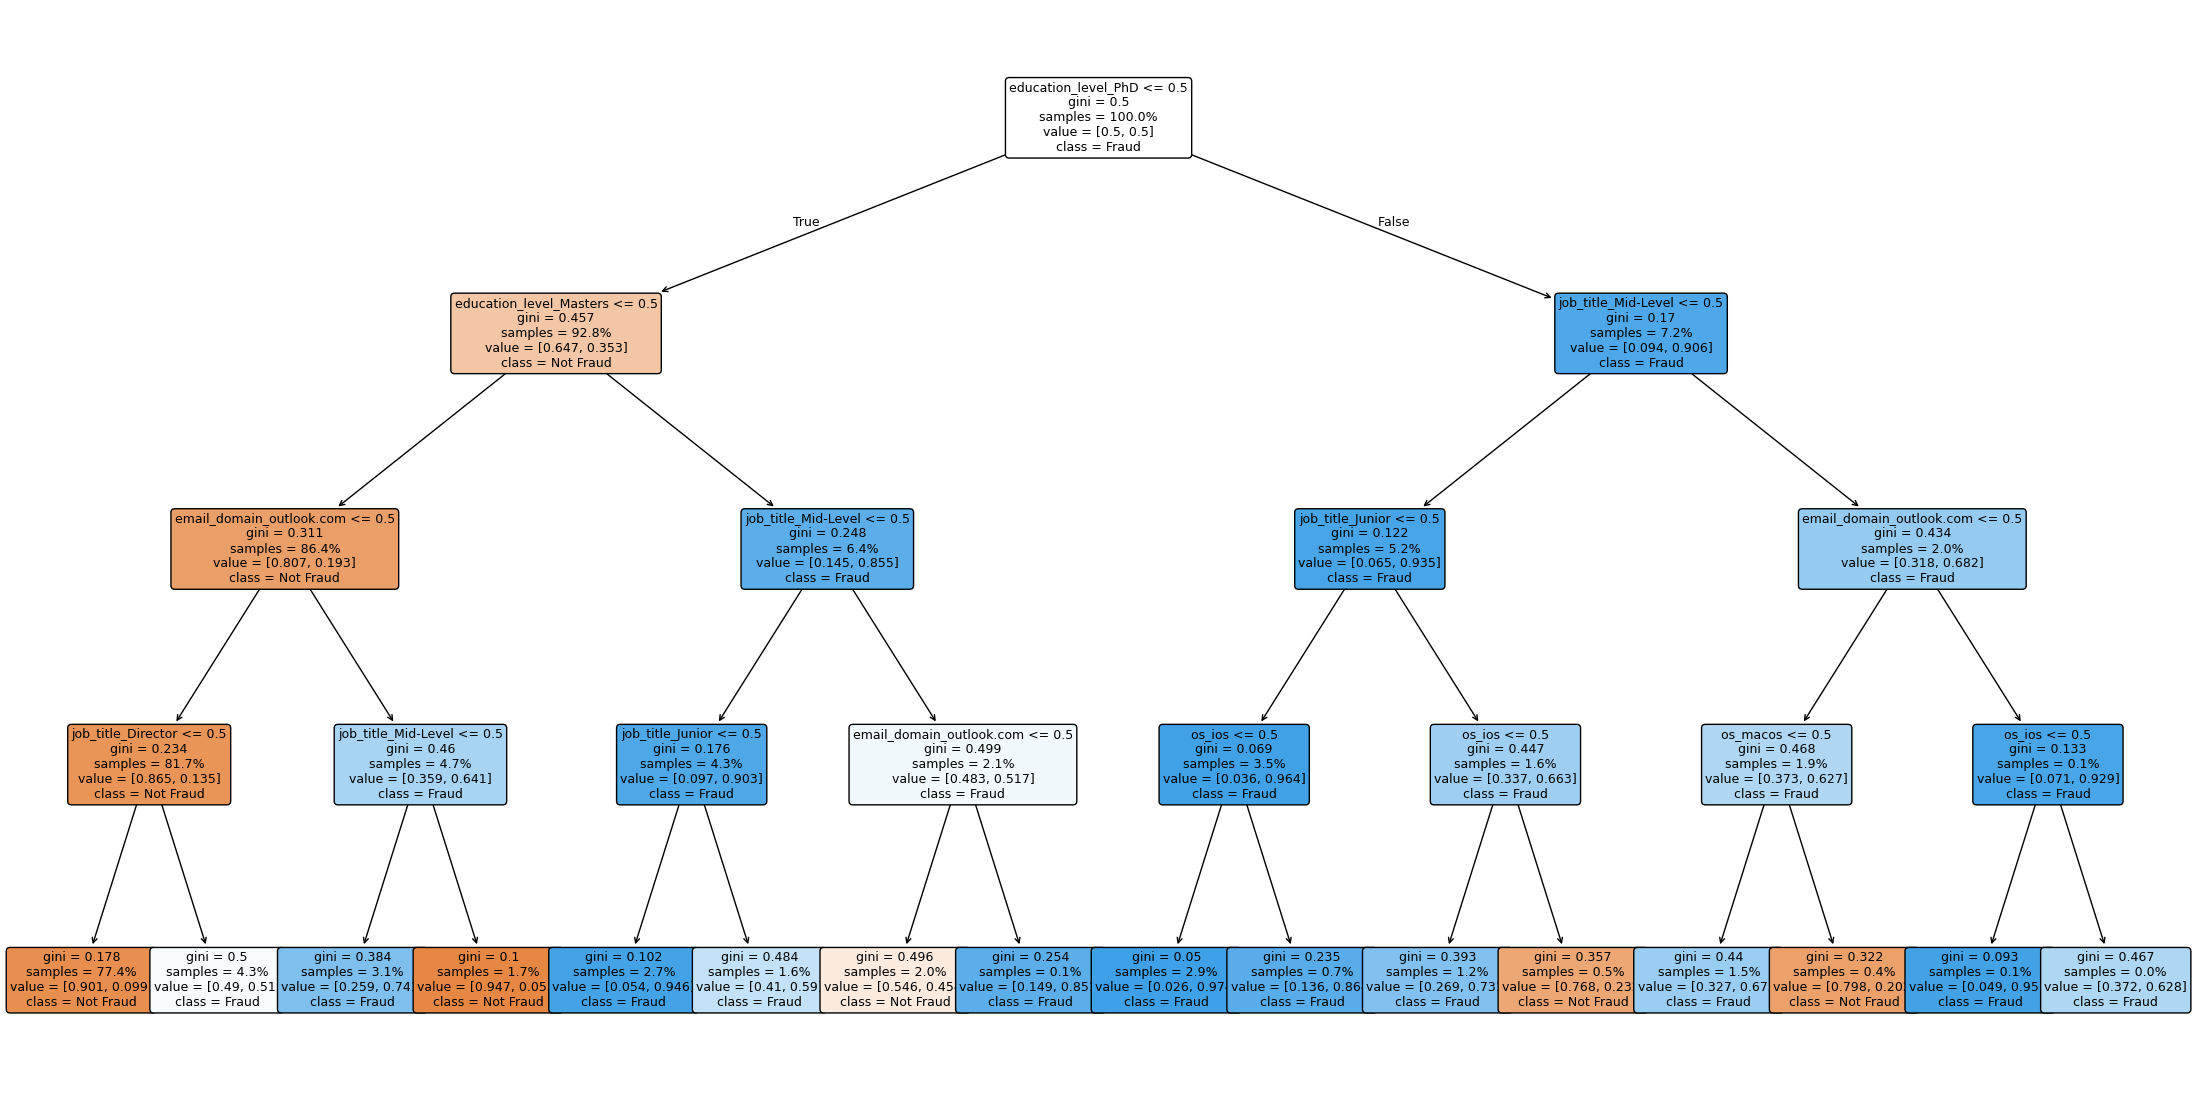

In [25]:
plt.figure(figsize=(28,14))

plot_tree(
    dt_model,
    feature_names=X_train_final.columns,
    class_names=["Not Fraud","Fraud"],
    filled=True,
    rounded=True,
    fontsize=9,
    proportion=True
)

plt.show()

### Observation from Decision Tree

The decision tree visualization showed that `job_title` and `education_level` were being represented as multiple independent binary features due to one-hot encoding (e.g., `job_title_Junior`, `job_title_Manager`, etc.). This approach does not preserve the natural ordering between the categories.

Since both variables have an inherent hierarchy, I converted them to **ordinal features** (`Junior < Mid-Level < Manager < Director < CEO` and `High School < Bachelors < Masters < PhD`). This encoding better represents the underlying relationships between categories and resulted in a more balanced model performance.